# Seasonal Agriculture Performance Analysis
 **Major Data Analytics Project**

 **Domain:**Agriculture

 **Project Theme**:Seasonal Agriculture Performance
**Tools:**Python,Pandas,Numpy,Matplotlib,Seaborn
 Project Goal
 Investigate how agricultural performance varies across all seasons that available in dataset and identify meaningful patterns,trends,relationships and difference in the available data.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [63]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [64]:
print('Dataset shape:')
df.shape

Dataset shape:


(4000, 28)

In [65]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [67]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [68]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [69]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [70]:
missing=df.isnull().sum().sort_values(ascending=False)
missing_percent=round(df.isnull().mean()*100).sort_values(ascending=False)
missing_summary=pd.DataFrame({"Missing_Count": missing,"Missing_Percent":missing_percent.round(2)})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.0
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,1.0


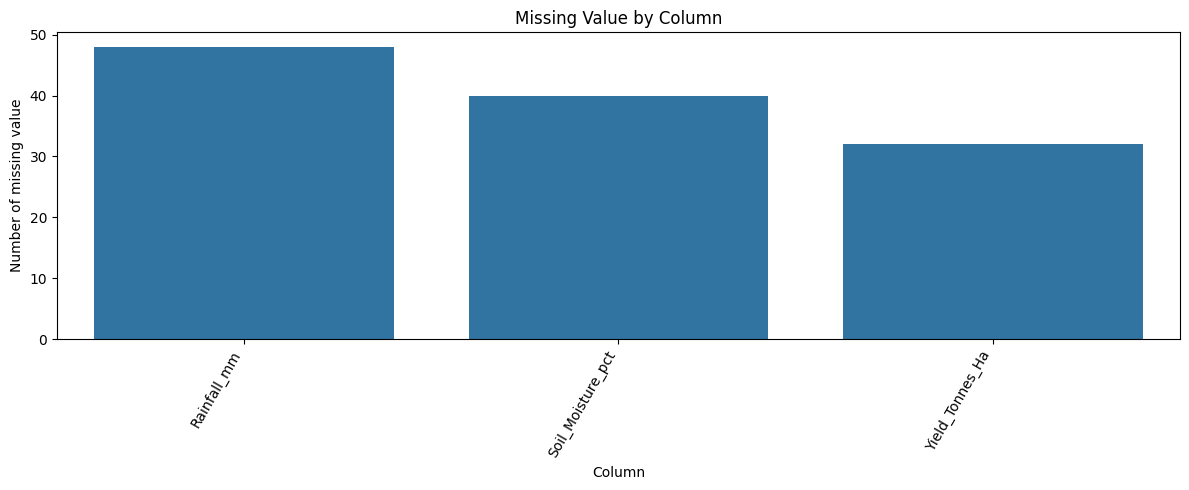

In [71]:
plt.figure(figsize=(12, 5))
missing_plot=missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60,ha="right")
  plt.ylabel("Number of missing value")
  plt.xlabel("Column")
plt.title('Missing Value by Column')
plt.tight_layout()
plt.show()

In [72]:
#MISSING VALUES ARE FILLING WITH MEDIAN.
missing_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())



In [73]:
# Check again after treatment
missing_after = df.isnull().sum()
missing_after[missing_after > 0]

,0


# Checking Duplicate Records
 duplicate records can affect counts,averages and statistical results,so they are checked before continuing the analysis.

In [74]:
duplicate_count=df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


The dataset contains 0 duplicate rows,so no duplicate records need to be removed.

In [75]:
#removing and reshaping the dataset if duplicates are present the dataset shape will be change
df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [76]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [77]:
categorical_columns=df.select_dtypes(include="object").columns
for col in categorical_columns:
  print(f"{col}:")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']
State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']
Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [78]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [79]:
#missing values are going to be replacing by median or some techinques
numeric_columns=df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum()>0:
      df[col]=df[col].fillna(df[col].median)
print("Remaining missing values:",df.isnull().sum().sum())

Remaining missing values: 0


In [80]:
#Outlier Detection
# Checking numerical columns for outliers

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

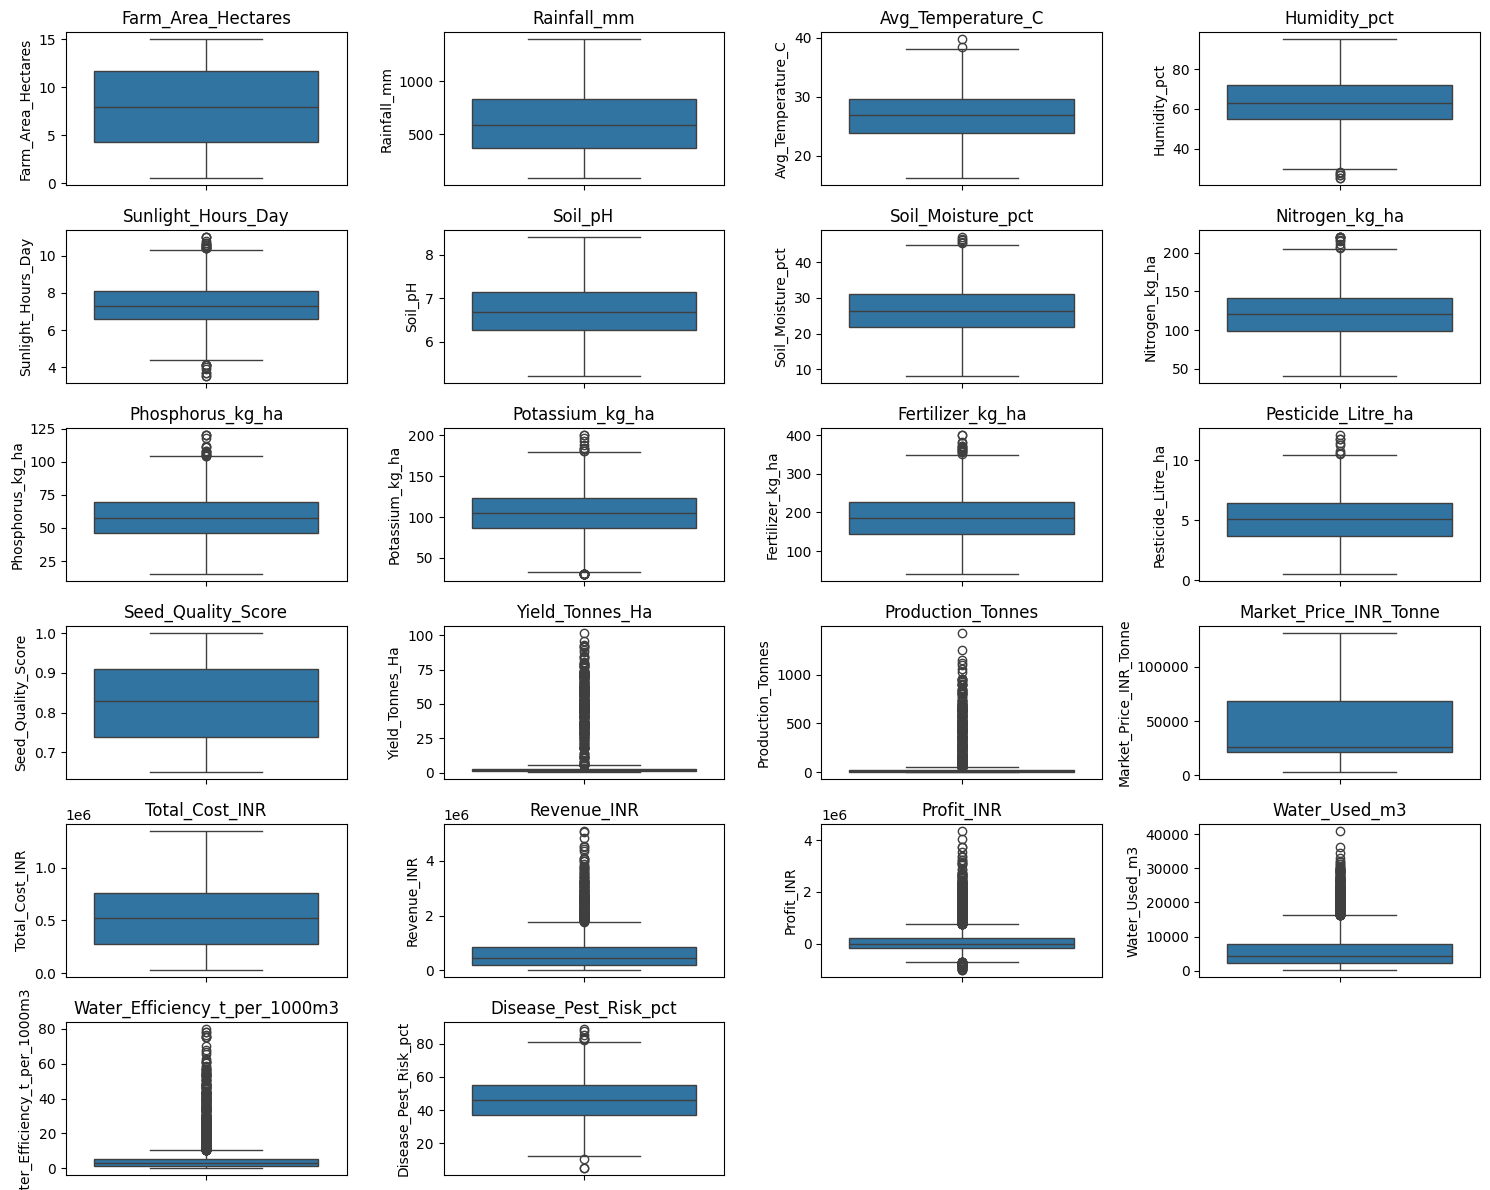

In [81]:
# Boxplots for numerical columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

By Observing above output the 15 numerical coulumns have outliers

In [82]:
# Finding the number of outliers in each numerical column

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outlier_summary.append([col, len(outliers)])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Number_of_Outliers']
)

outlier_summary = outlier_summary[
    outlier_summary['Number_of_Outliers'] > 0
]

outlier_summary

,Column,Number_of_Outliers
2,Avg_Temperature_C,2
3,Humidity_pct,6
4,Sunlight_Hours_Day,26
6,Soil_Moisture_pct,5
7,Nitrogen_kg_ha,10
8,Phosphorus_kg_ha,16
9,Potassium_kg_ha,32
10,Fertilizer_kg_ha,15
11,Pesticide_Litre_ha,8
13,Yield_Tonnes_Ha,302


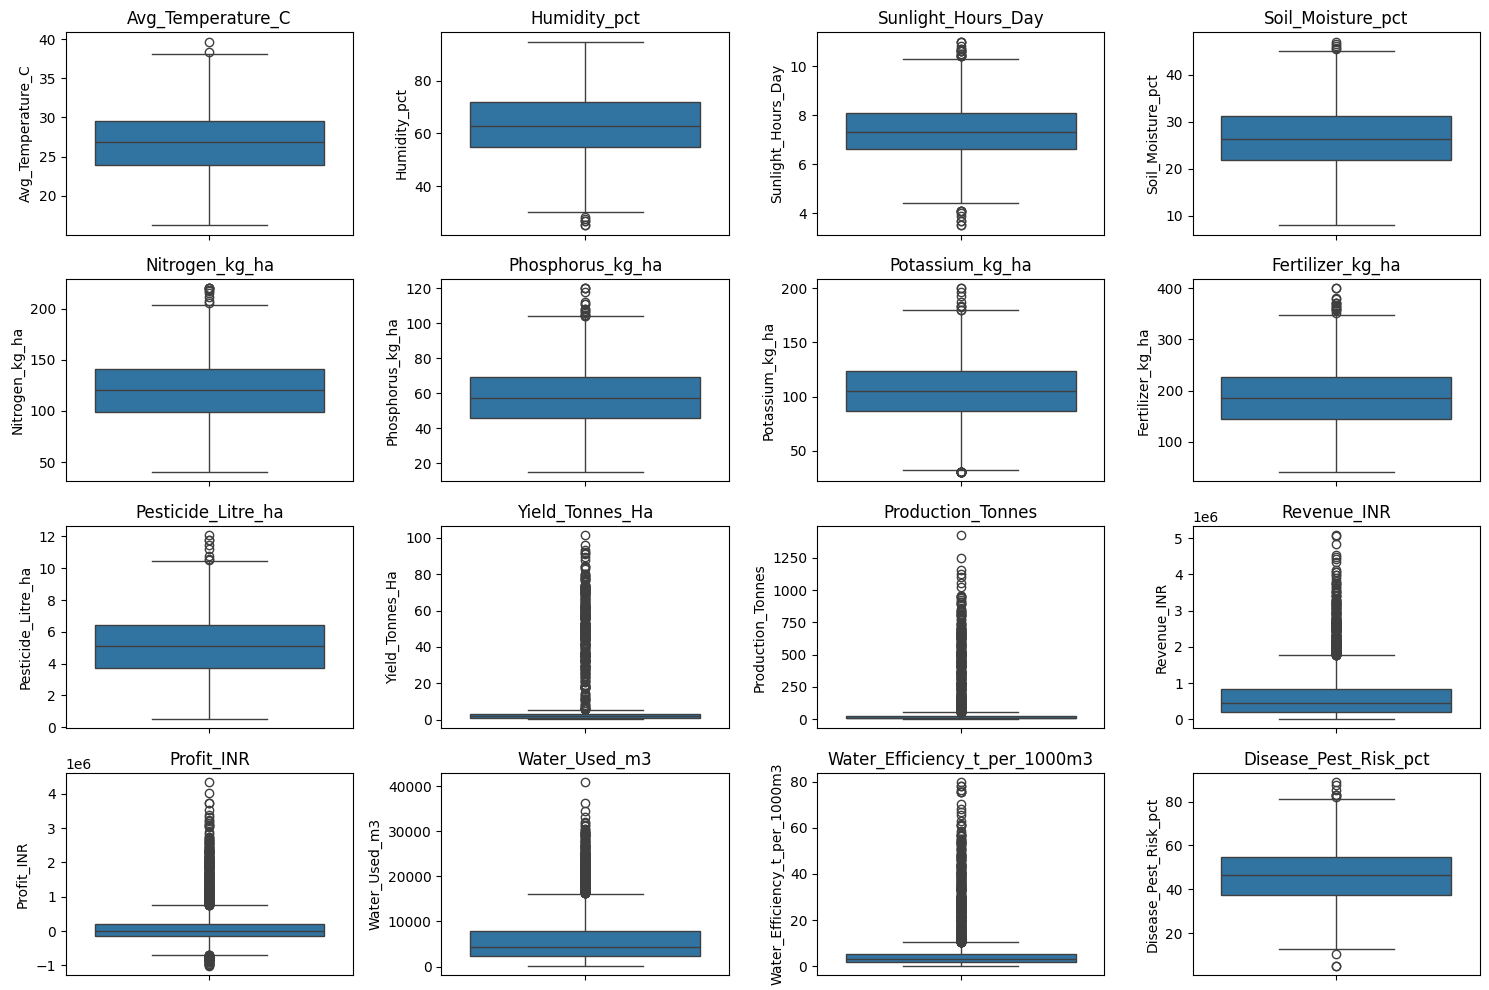

In [83]:
# Boxplots of columns having outliers

outlier_columns = outlier_summary['Column']

plt.figure(figsize=(15, 10))

for i, col in enumerate(outlier_columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()


### Outlier Detection Results

**The boxplots and IQR method were used to identify potential outliers in the numerical variables. Outliers were found in 15 numerical columns.

**The highest number of potential outliers was observed in Yield_Tonnes_Ha, Production_Tonnes, Profit_INR, Water_Used_m3, and Water_Efficiency_t_per_1000m3. These values may represent genuine differences in agricultural performance rather than incorrect data.

**Therefore, the detected outliers are not removed at this stage. They will be retained for further analysis because extreme agricultural values may provide useful information about seasonal performance and resource usage.

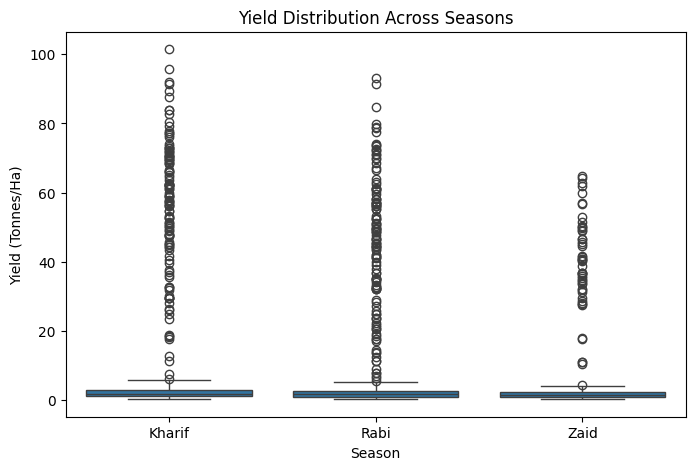

In [84]:
# Boxplot of yield across different seasons

plt.figure(figsize=(8, 5))

sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

### Interpretation of Yield Boxplot

The boxplot shows the distribution of yield across Kharif, Rabi, and Zaid seasons. All three seasons contain potential high-value outliers. Kharif and Rabi show a larger number of extreme yield observations compared with Zaid. These observations may represent farms with unusually high agricultural performance. Therefore, the outliers are retained for further analysis rather than being removed.

# Univariate Analysis

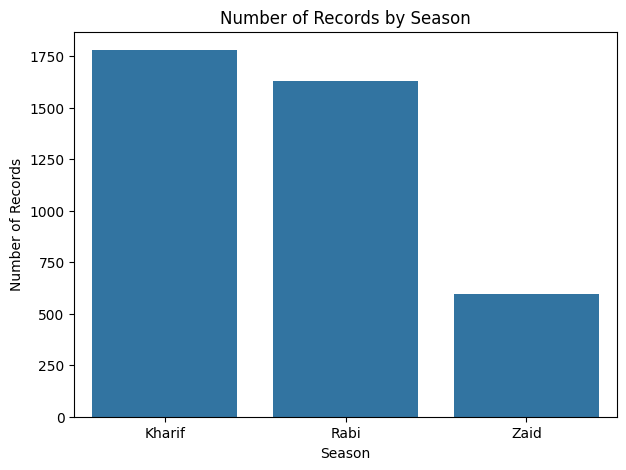

In [85]:
# Distribution of agricultural records across seasons

plt.figure(figsize=(7, 5))

sns.countplot(x='Season', data=df)

plt.title('Number of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()

### Interpretation

The countplot shows that Kharif has the highest number of records, followed by Rabi. Zaid has the lowest number of records among the three seasons.

**Crop distribution**

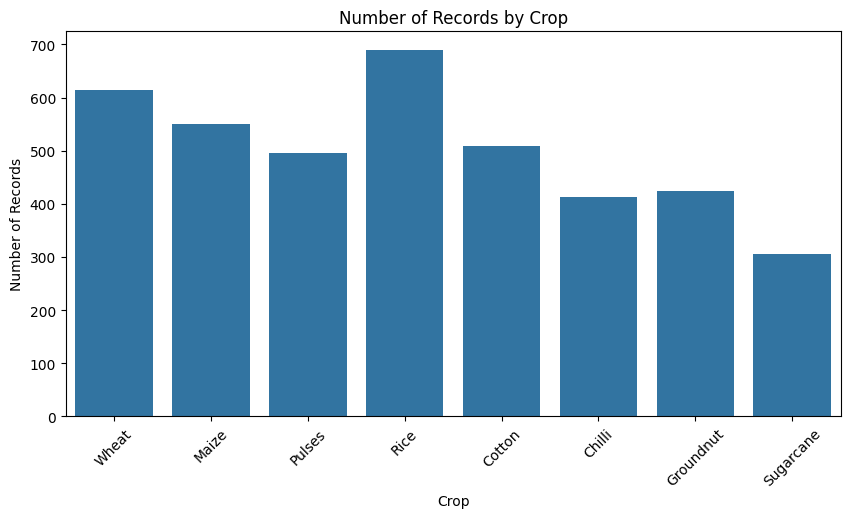

In [86]:
# Distribution of records across different crops

plt.figure(figsize=(10, 5))

sns.countplot(x='Crop', data=df)

plt.title('Number of Records by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.show()

### Interpretation

The countplot shows that Rice has the highest number of records, followed by Wheat. Maize and Cotton have a moderate number of records, while Pulses, Groundnut, and Chilli have fewer records. Sugarcane has the lowest number of records among the crops.


**Irrigation Method**

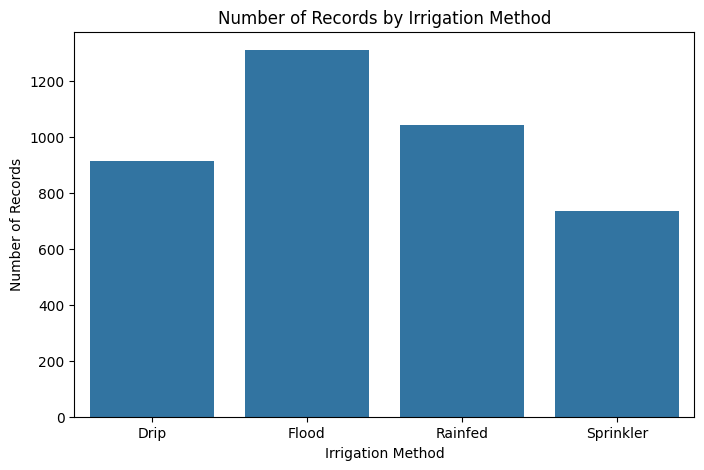

In [87]:
# Distribution of records across irrigation methods

plt.figure(figsize=(8, 5))

sns.countplot(x='Irrigation_Method', data=df)

plt.title('Number of Records by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Records')

plt.show()

### Interpretation

The countplot shows the distribution of agricultural records across the different irrigation methods: Flood, Rainfed, Drip, and Sprinkler. The number of records varies across the irrigation methods, indicating that the dataset contains different levels of representation for each method.

# Numerical Univariate Analysis

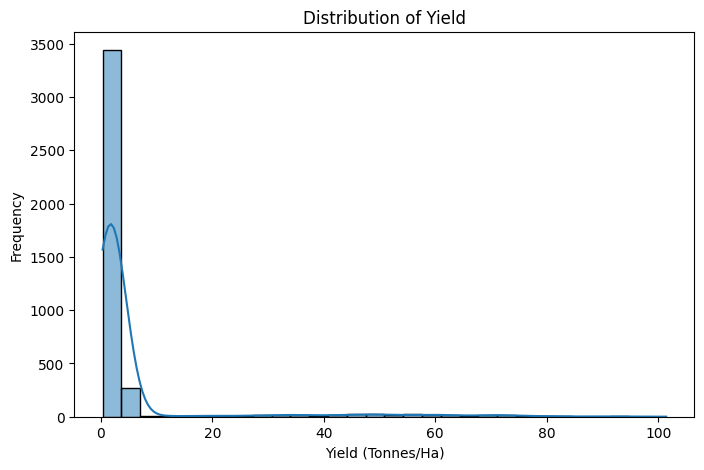

In [88]:
# Distribution of yield

plt.figure(figsize=(8, 5))

sns.histplot(df['Yield_Tonnes_Ha'], bins=30, kde=True)

plt.title('Distribution of Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows that the distribution of yield is right-skewed. Most of the observations have relatively lower yield values, while a smaller number of observations have very high yields. This indicates considerable variation in agricultural yield across the farms.

**Rainfall**

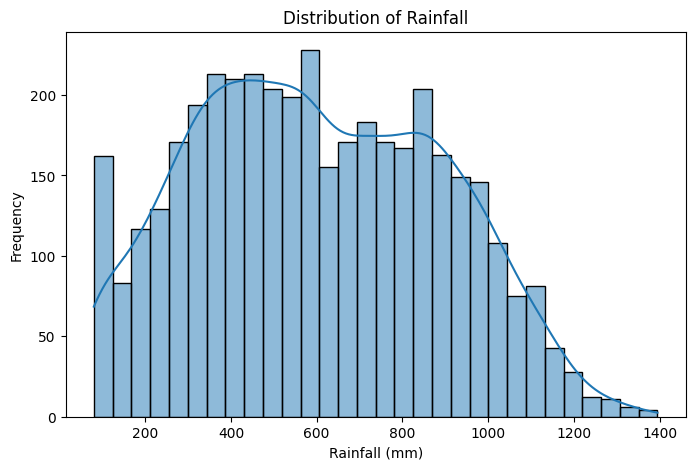

In [89]:
# Distribution of rainfall

plt.figure(figsize=(8, 5))

sns.histplot(df['Rainfall_mm'], bins=30, kde=True)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of rainfall across the farms. Most observations are concentrated between approximately 300 mm and 1,000 mm. There are fewer observations at very high rainfall levels, resulting in a slight right-skewed distribution.

**Temperature**

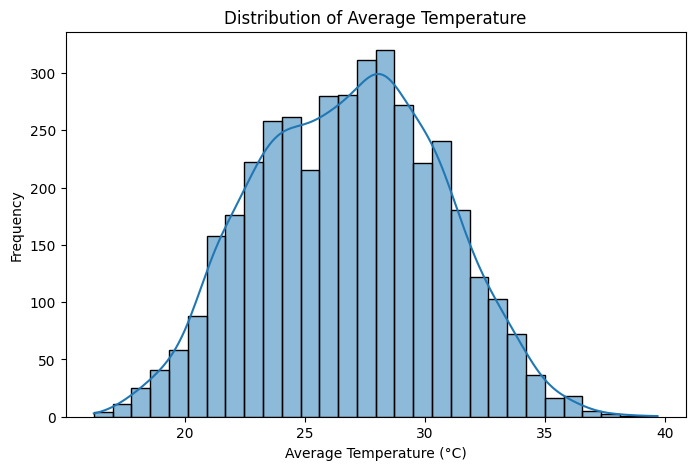

In [90]:
# Distribution of average temperature

plt.figure(figsize=(8, 5))

sns.histplot(df['Avg_Temperature_C'], bins=30, kde=True)

plt.title('Distribution of Average Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of average temperature across the farms. Most temperature values are concentrated between approximately 23°C and 31°C, with the highest frequency around 27°C to 29°C. The distribution is approximately bell-shaped, with fewer observations at very low and very high temperatures.

**Humidity**

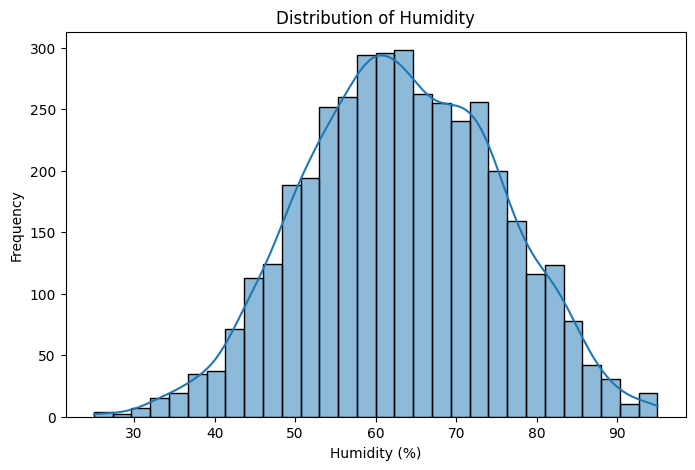

In [91]:
# Distribution of humidity

plt.figure(figsize=(8, 5))

sns.histplot(df['Humidity_pct'], bins=30, kde=True)

plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows that most humidity values are concentrated between approximately 50% and 75%. The highest frequency is observed around 60% to 65%. Very low and very high humidity values occur less frequently. Overall, the distribution is approximately bell-shaped.

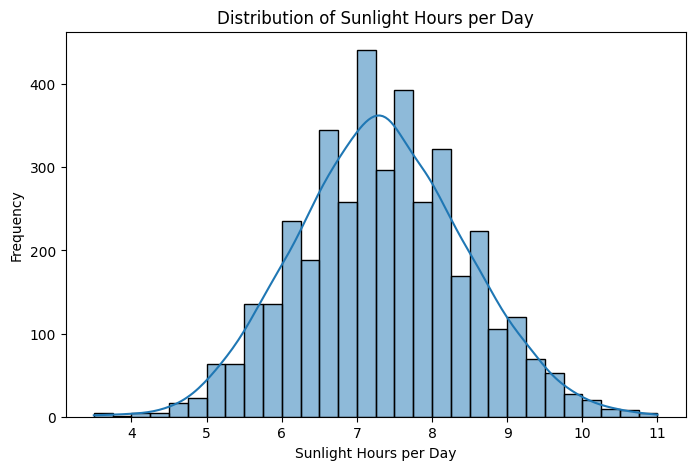

In [92]:
# Distribution of sunlight hours per day

plt.figure(figsize=(8, 5))

sns.histplot(df['Sunlight_Hours_Day'], bins=30, kde=True)

plt.title('Distribution of Sunlight Hours per Day')
plt.xlabel('Sunlight Hours per Day')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows that most farms receive approximately 6 to 9 hours of sunlight per day. The highest frequency is observed around 7 to 8 hours per day. Very low and very high sunlight values occur less frequently. Overall, the distribution is approximately bell-shaped.

Soil **pH**

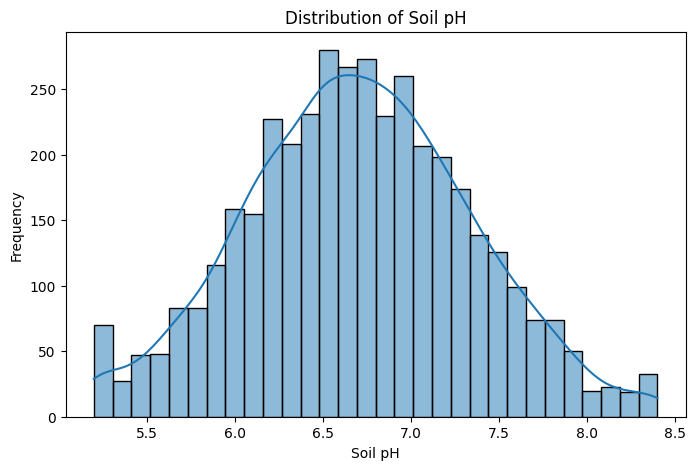

In [93]:
# Distribution of soil pH

plt.figure(figsize=(8, 5))

sns.histplot(df['Soil_pH'], bins=30, kde=True)

plt.title('Distribution of Soil pH')
plt.xlabel('Soil pH')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows that most soil pH values are concentrated between approximately 6.0 and 7.5. The highest frequency is observed around 6.5 to 7.0. Fewer farms have very low or very high soil pH values. Overall, the distribution is approximately bell-shaped.

Soil Moisture

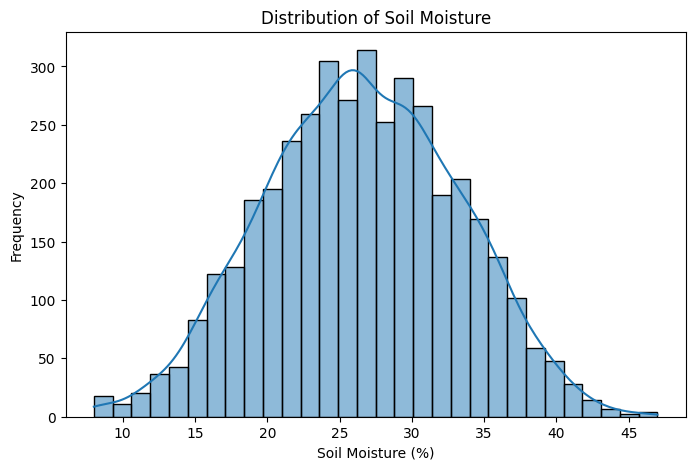

In [94]:
# Distribution of soil moisture

plt.figure(figsize=(8, 5))

sns.histplot(df['Soil_Moisture_pct'], bins=30, kde=True)

plt.title('Distribution of Soil Moisture')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Frequency')

plt.show()

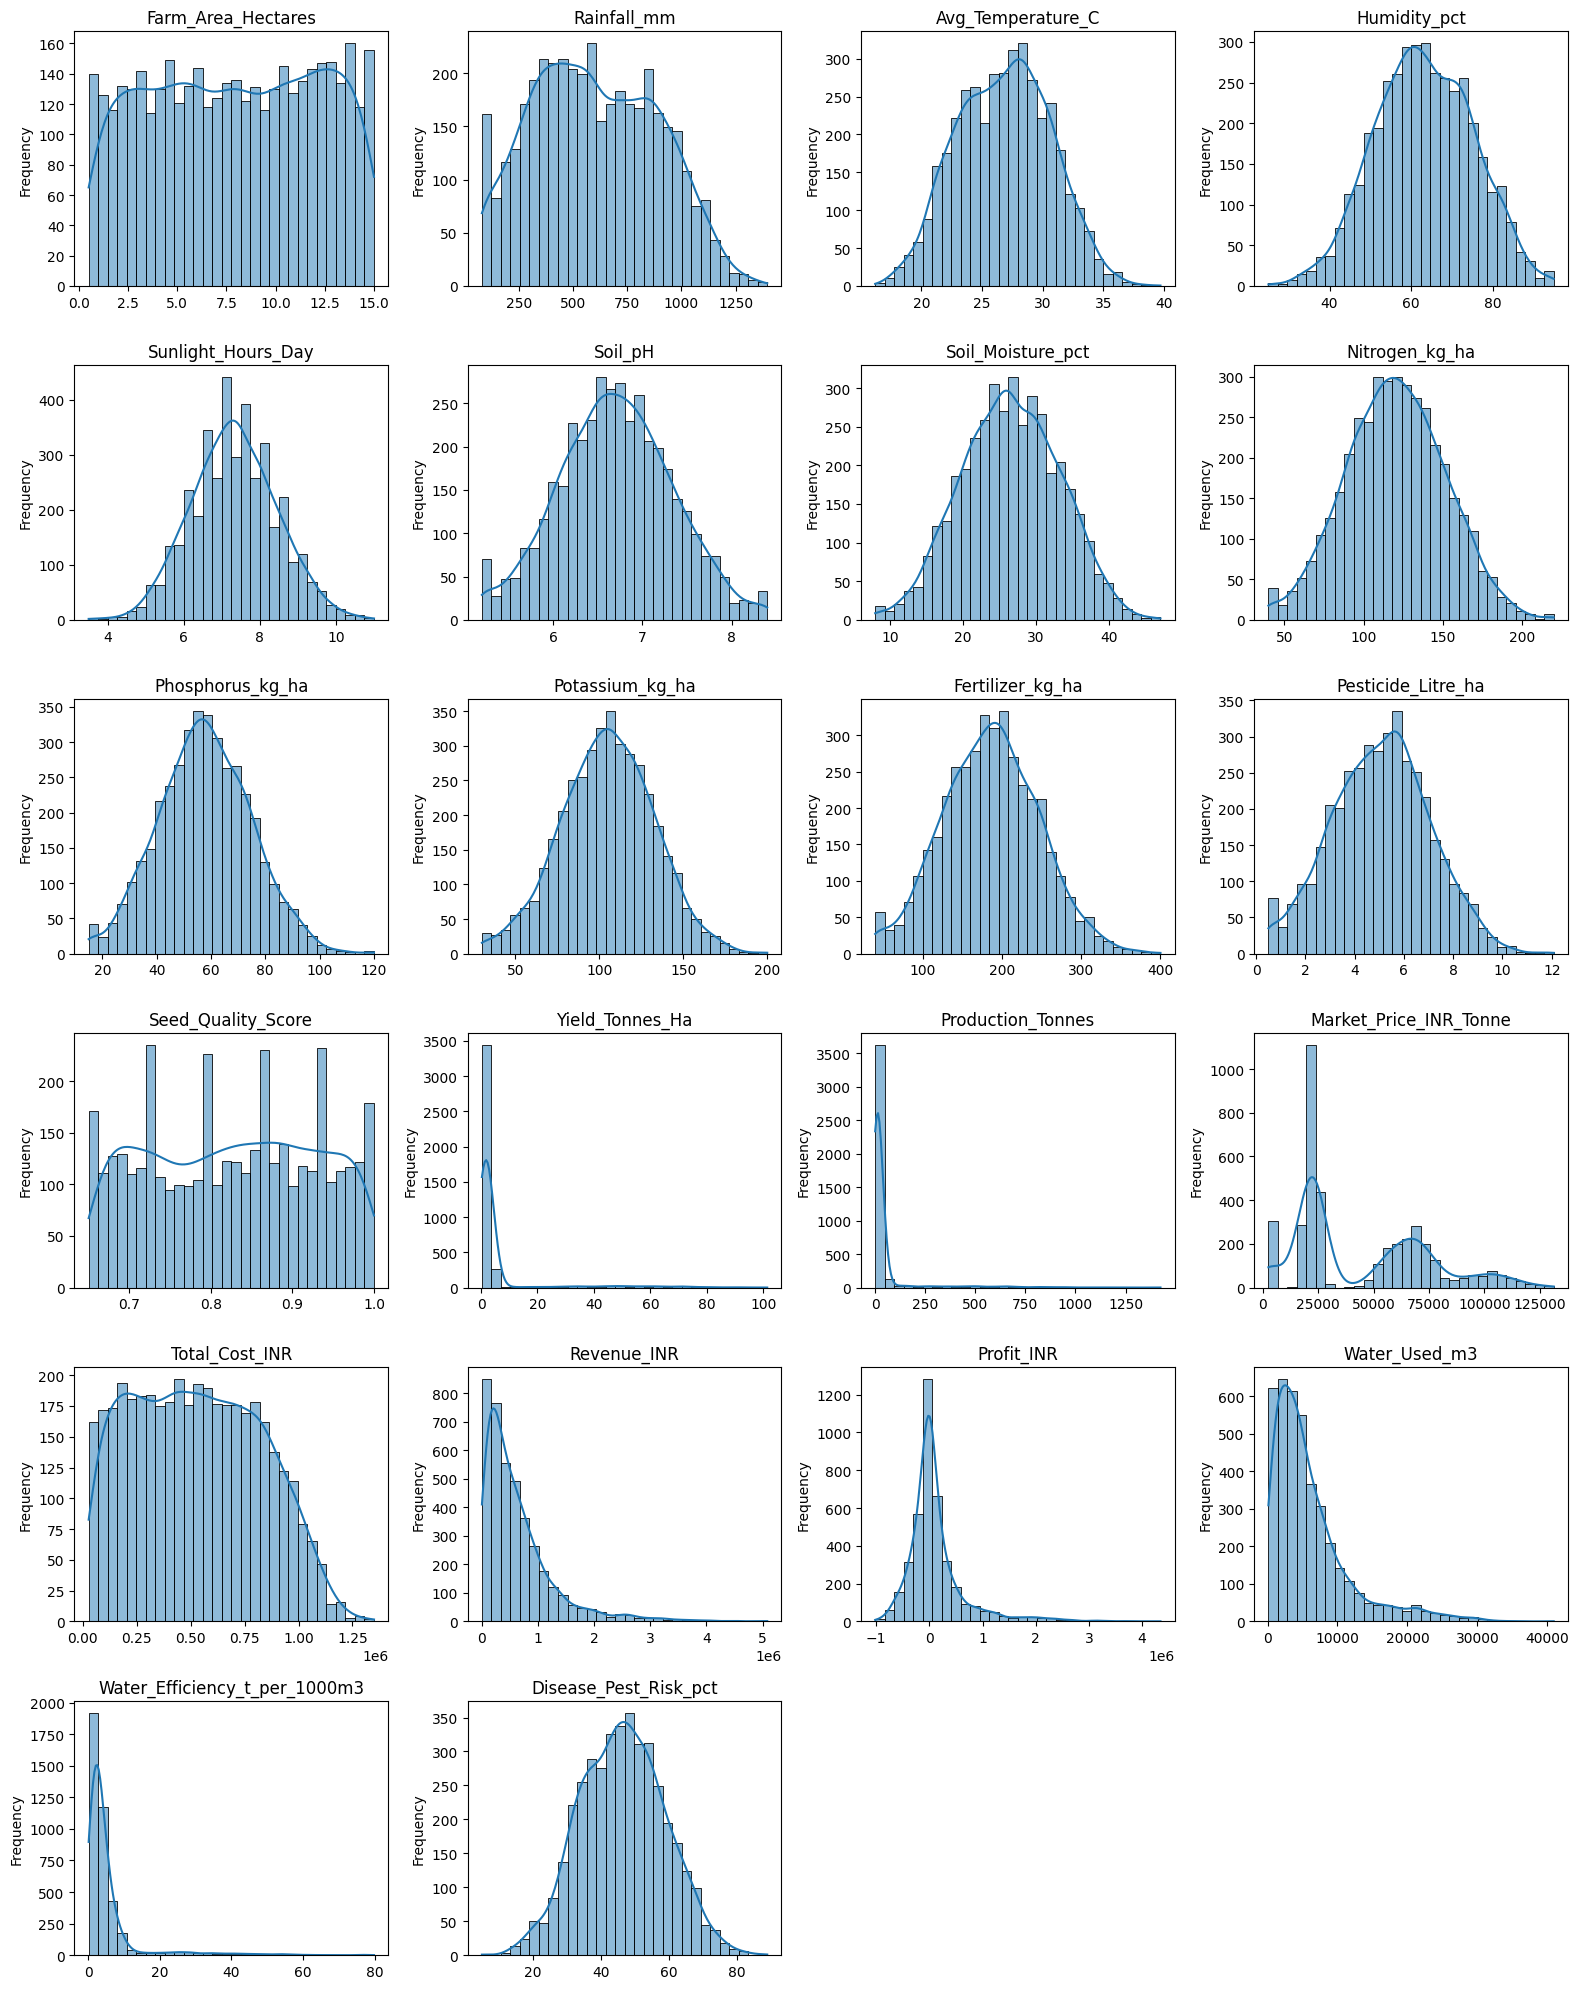

In [95]:
# Univariate analysis of numerical variables

plt.figure(figsize=(16, 20))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(6, 4, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation

The histograms show the distributions of the numerical variables in the dataset. Most environmental variables such as temperature, humidity, sunlight hours, and soil pH show approximately bell-shaped distributions. Variables related to yield, production, revenue, profit, water usage, and water efficiency show greater variation and are more right-skewed due to the presence of high-value observations.

# **Bivariate Analysis**
Bivariate analysis studies the relationship between two variables

**Average Yield by Season**

## 7. Bivariate Analysis

Bivariate analysis is used to study the relationship between two variables and understand how agricultural performance changes with different seasons, environmental conditions, and resource usage.

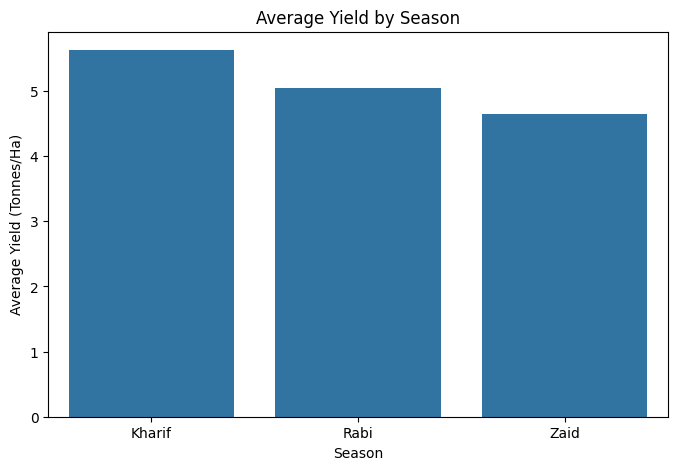

In [96]:
# Average yield by season

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=season_yield)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [97]:
season_yield

,Season,Yield_Tonnes_Ha
0,Kharif,5.628612
1,Rabi,5.039435
2,Zaid,4.641313


### Interpretation

The bar chart shows differences in average yield across the three seasons. Kharif has the highest average yield, followed by Rabi, while Zaid has the lowest average yield. This indicates that seasonal conditions are associated with differences in agricultural yield.

**Season vs Profit**

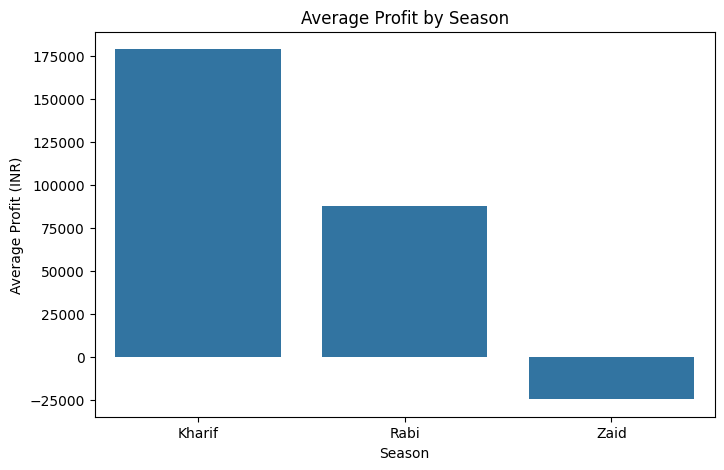

In [98]:
# Average profit by season

season_profit = df.groupby('Season')['Profit_INR'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(x='Season', y='Profit_INR', data=season_profit)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

In [99]:
season_profit

,Season,Profit_INR
0,Kharif,178914.647555
1,Rabi,87689.470191
2,Zaid,-24804.824916


### Interpretation

The bar chart shows that average profit varies across seasons. Kharif has the highest average profit, while Zaid has the lowest average profit. The average profit for Zaid is negative, indicating that the average revenue is lower than the average cost in this season.

**Irrigation Method vs Yield**

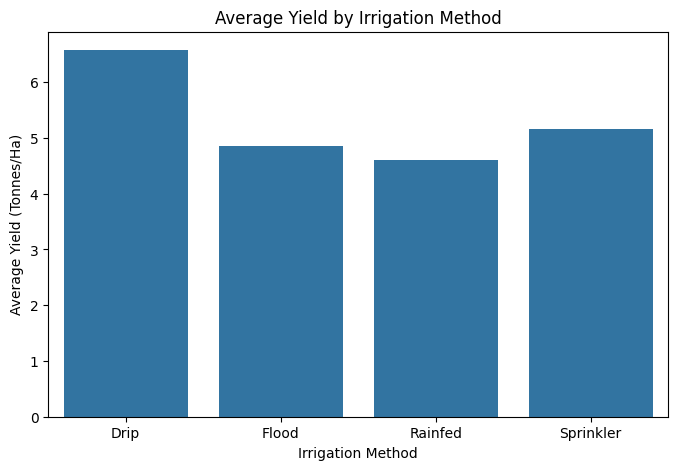

In [100]:
# Average yield by irrigation method

irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(x='Irrigation_Method', y='Yield_Tonnes_Ha', data=irrigation_yield)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [101]:
irrigation_yield

,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.577989
1,Flood,4.863977
2,Rainfed,4.602142
3,Sprinkler,5.160627


### Interpretation

The bar chart shows that average yield differs across irrigation methods. Drip irrigation has the highest average yield among the different irrigation methods. This suggests that irrigation method is associated with differences in agricultural yield.

**Rainfall vs Yield**

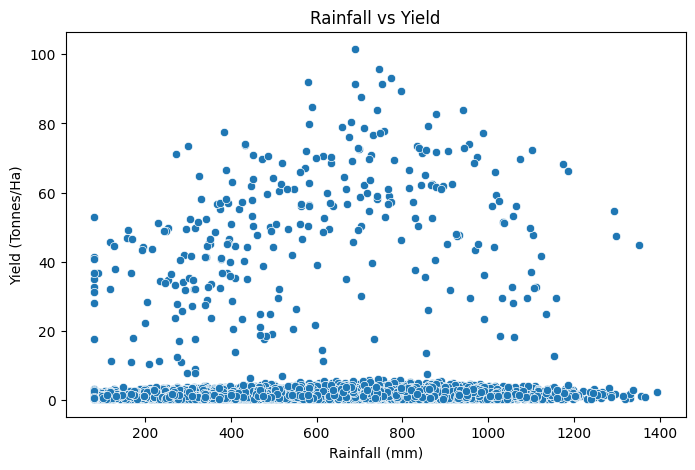

In [102]:
# Relationship between rainfall and yield

plt.figure(figsize=(8, 5))

sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [103]:
# Correlation between rainfall and yield

df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

np.float64(0.030950993551650874)

### Interpretation
The correlation between rainfall and yield is approximately 0.031, which indicates a very weak positive relationship. This means that changes in rainfall alone do not show a strong relationship with yield in this dataset. Other factors such as temperature, soil conditions, irrigation, and fertilizer may also influence agricultural yield.

**Temperature vs Yield**

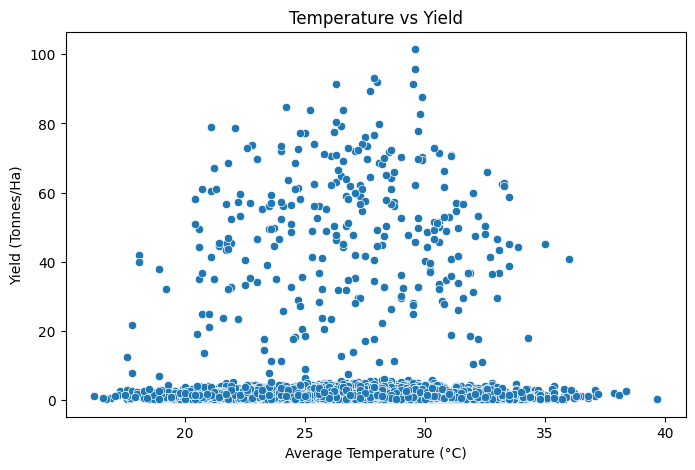

In [104]:
# Relationship between temperature and yield
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Avg_Temperature_C', y='Yield_Tonnes_Ha', data=df)
plt.title('Temperature vs Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [105]:
# Correlation between temperature and yield
df['Avg_Temperature_C'].corr(df['Yield_Tonnes_Ha'])

np.float64(0.009996320546703593)

### Interpretation
The correlation between average temperature and yield is approximately 0.010, which indicates an almost negligible positive relationship. This suggests that temperature alone does not have a strong linear relationship with yield in this dataset. Other factors may have a greater influence on agricultural yield.

**Fertilizer vs Yield**

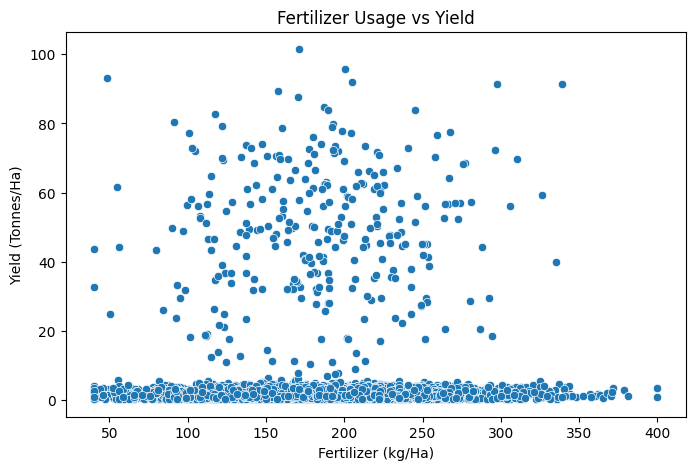

In [106]:
# Relationship between fertilizer usage and yield
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', data=df)
plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/Ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [107]:
# Correlation between fertilizer usage and yield
df['Fertilizer_kg_ha'].corr(df['Yield_Tonnes_Ha'])

np.float64(1.7712703696042472e-05)

### Interpretation
The correlation between fertilizer usage and yield is approximately 0.00002, which indicates an almost zero linear relationship. This suggests that fertilizer usage alone does not show a meaningful linear relationship with yield in this dataset. Other agricultural and environmental factors may influence yield.

**Water Used vs Yield**

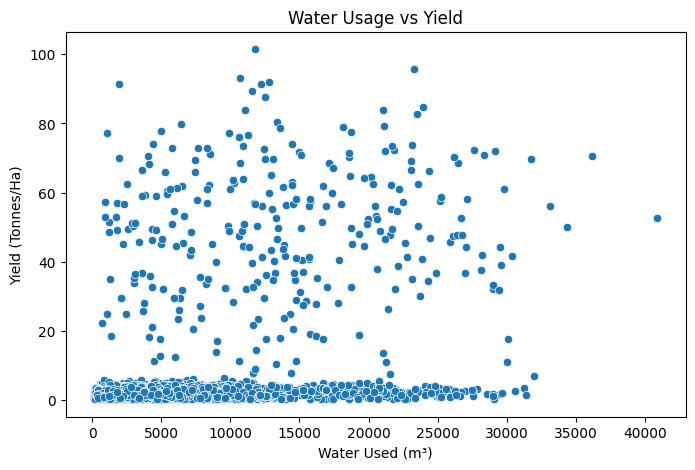

In [108]:
# Relationship between water usage and yield
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Water_Used_m3', y='Yield_Tonnes_Ha', data=df)
plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [109]:
# Correlation between water usage and yield
df['Water_Used_m3'].corr(df['Yield_Tonnes_Ha'])



np.float64(0.38629381188867173)

### Interpretation
The correlation between water usage and yield is approximately 0.386, indicating a moderate positive relationship. This suggests that higher water usage is generally associated with higher yield in the dataset. However, the relationship is not very strong, so other factors may also influence agricultural yield.

| Variables            | Correlation |  Interpretation         |
| -------------------- | ----------: | ---------------------- |
| Rainfall vs Yield    |       0.031 | Very weak positive     |
| Temperature vs Yield |       0.010 | Almost no relationship |
| Fertilizer vs Yield  |     0.00002 | Almost no relationship |
| Water Used vs Yield  |       0.386 | Moderate positive      |


# Multivariate Analysis

## 8. Multivariate Analysis

Multivariate analysis is used to study multiple variables together and understand how different factors are related to agricultural performance.

**Correlation Heatmap**

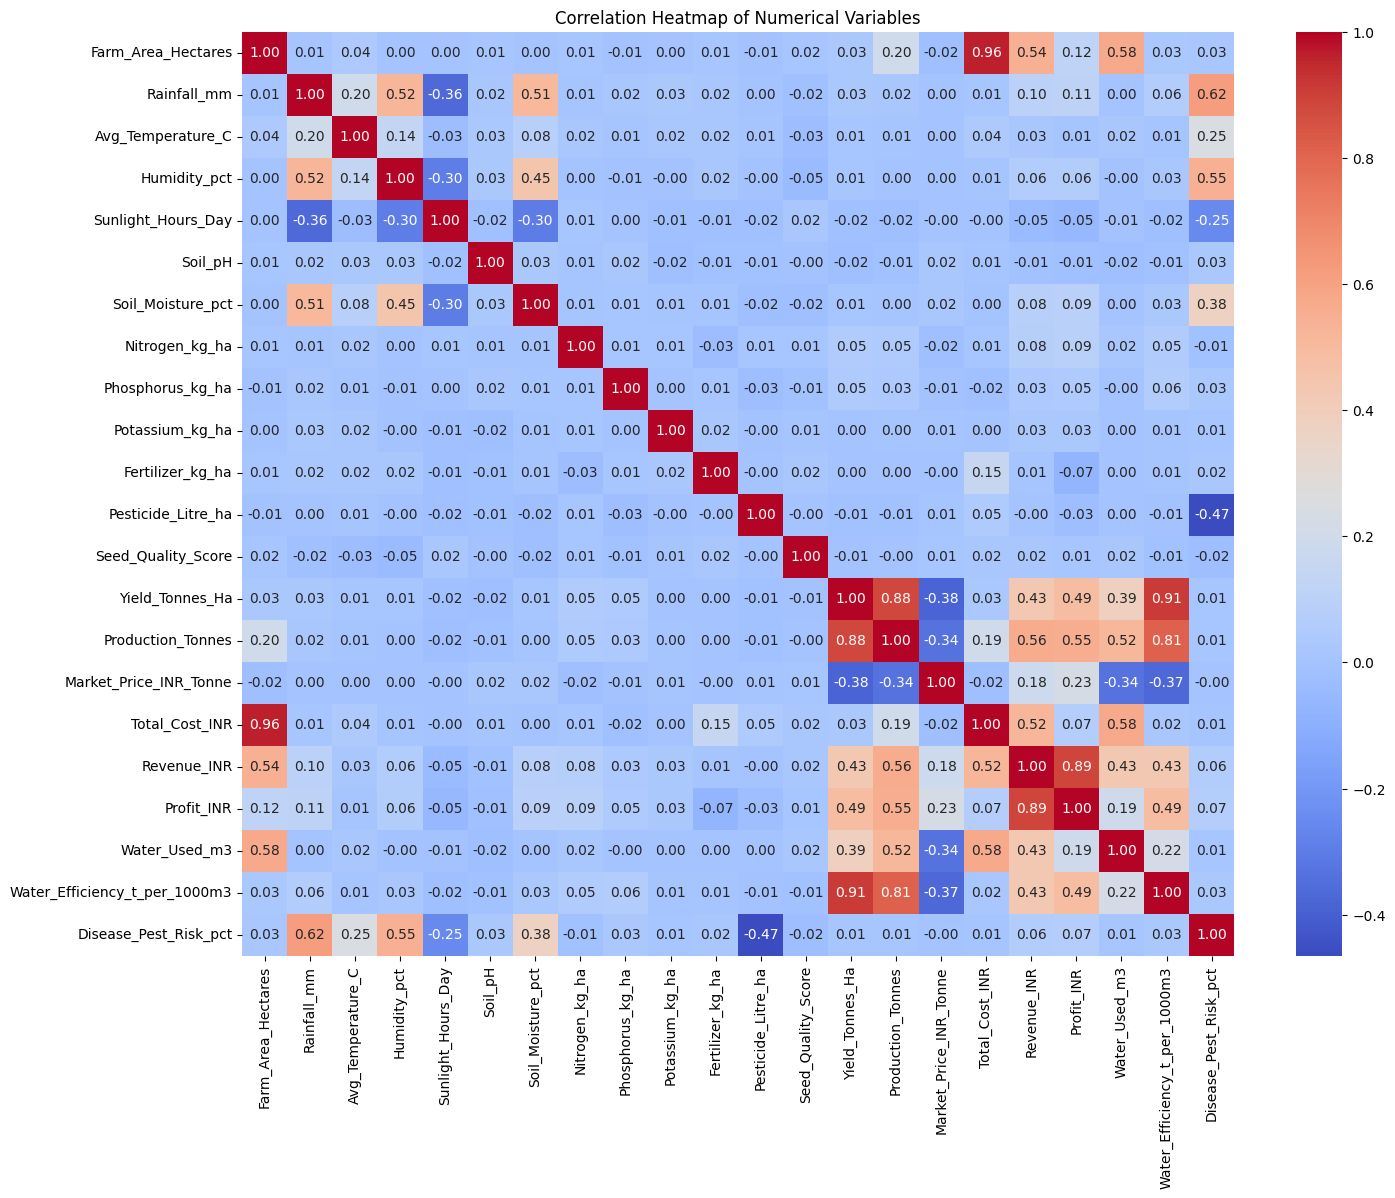

In [110]:
# Correlation heatmap of numerical variables
plt.figure(figsize=(16, 12))

correlation_matrix = df[numerical_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Interpretation

The correlation heatmap shows the relationships between the numerical variables in the dataset. Yield has a moderate positive relationship with water usage, while rainfall, temperature, and fertilizer usage show very weak relationships with yield. The heatmap also shows that some production and financial variables are strongly related to each other because they are connected to agricultural output and revenue.

**Season and Irrigation Method vs Yield**

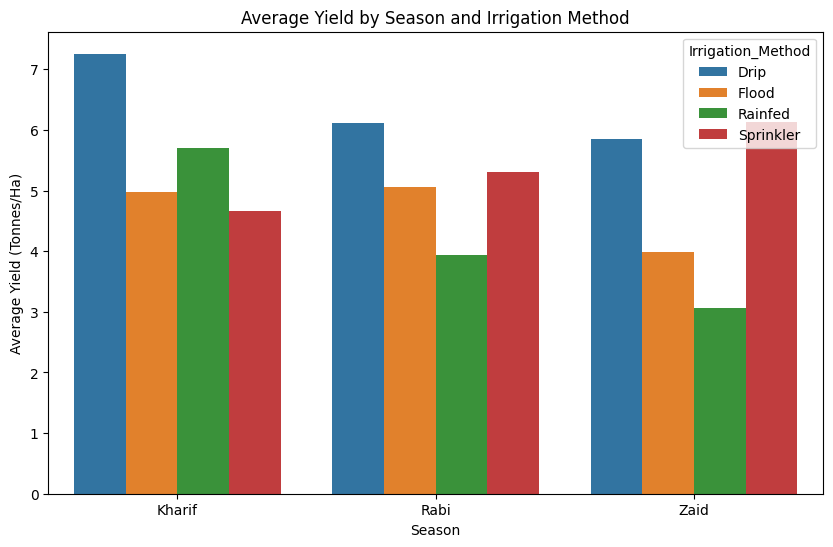

In [111]:
# Average yield by season and irrigation method
season_irrigation_yield = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method',
    data=season_irrigation_yield
)

plt.title('Average Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

### Interpretation

The grouped bar chart shows that average yield varies across both seasons and irrigation methods. Drip irrigation has the highest average yield in Kharif, while it also performs well in Rabi and Zaid. In Kharif, Rainfed irrigation has a higher average yield than Flood and Sprinkler. In Rabi, Sprinkler has a higher average yield than Rainfed and Flood. In Zaid, Sprinkler has the highest average yield, followed by Drip.

Overall, the results show that the relationship between irrigation method and yield varies across seasons. Drip and Sprinkler generally show better yield performance compared with the other methods.

**Season and Irrigation Method vs Profit**

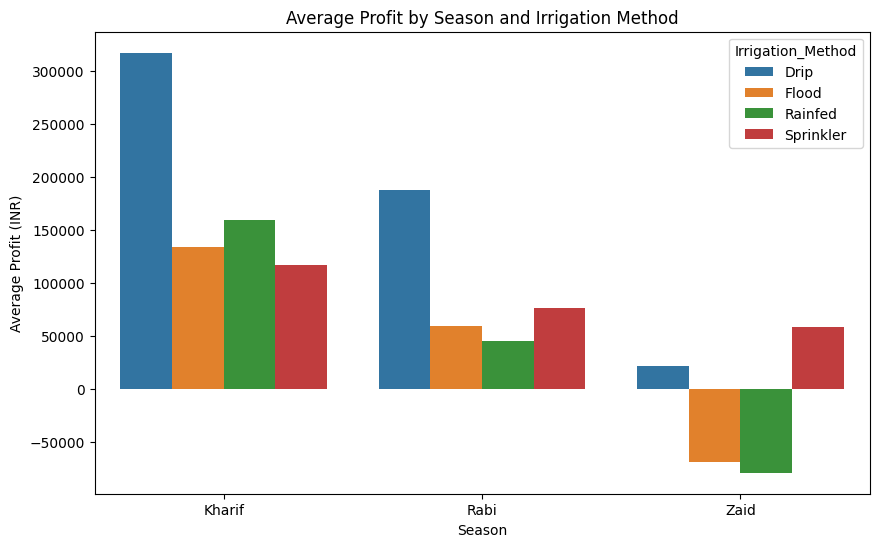

In [112]:
# Average profit by season and irrigation method
season_irrigation_profit = df.groupby(
    ['Season', 'Irrigation_Method']
)['Profit_INR'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Season',
    y='Profit_INR',
    hue='Irrigation_Method',
    data=season_irrigation_profit
)

plt.title('Average Profit by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

### Interpretation

The grouped bar chart shows that average profit varies across both seasons and irrigation methods. Drip irrigation has the highest average profit in Kharif and Rabi. In Zaid, Drip and Sprinkler have positive average profits, while Flood and Rainfed show negative average profits.

Overall, Kharif shows better profit performance across all irrigation methods. Zaid shows much lower profitability, with some irrigation methods resulting in negative average profit. This indicates that both season and irrigation method are important when comparing agricultural profitability.

**Season and Crop vs Yield**

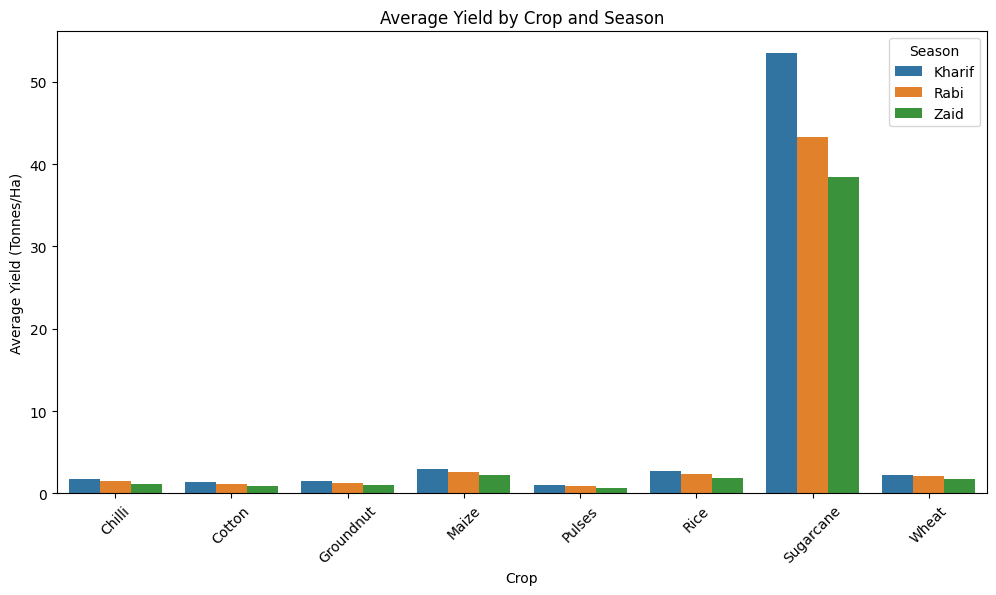

In [113]:
# Average yield by season and crop
season_crop_yield = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season',
    data=season_crop_yield
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

### Interpretation

The chart shows that average yield varies across crops and seasons. Sugarcane has the highest average yield in Kharif, Rabi, and Zaid seasons. Maize and Rice also show relatively higher yields compared with most other crops. Pulses, Cotton, Groundnut, and Chilli have comparatively lower average yields.

Overall, the results show that crop type has an important role in agricultural yield, and the yield of some crops also changes across seasons.

**Seasonal Comparisons**

In [114]:
# Seasonal comparison of important performance measures

seasonal_comparison = df.groupby('Season')[
    ['Yield_Tonnes_Ha',
     'Profit_INR',
     'Water_Efficiency_t_per_1000m3']
].mean()

seasonal_comparison

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,
Kharif,5.628612,178914.647555,5.891834
Rabi,5.039435,87689.470191,5.186122
Zaid,4.641313,-24804.824916,4.413239


### Interpretation

The seasonal comparison shows clear differences in agricultural performance across Kharif, Rabi, and Zaid seasons.

Kharif has the highest average yield of 5.63 tonnes/ha, followed by Rabi with 5.04 tonnes/ha and Zaid with 4.64 tonnes/ha. Kharif also has the highest average profit of approximately ₹178,915, while Zaid has a negative average profit of approximately ₹24,805.

Water efficiency is also highest in Kharif at 5.89 tonnes per 1000 m³ of water, followed by Rabi at 5.19 and Zaid at 4.41.

Overall, Kharif shows the best performance among the three seasons in terms of yield, profit, and water efficiency. Zaid shows comparatively lower agricultural and economic performance.

**Seasonal Environmental Comparison**

In [115]:
# Seasonal comparison of environmental conditions

seasonal_environment = df.groupby('Season')[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct']
].mean()

seasonal_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,
Kharif,849.199663,28.454019,71.812591
Rabi,437.615366,23.489183,57.893178
Zaid,304.654714,31.042088,52.012121


### Interpretation

The seasonal comparison shows clear differences in environmental conditions. Kharif has the highest average rainfall of about 849.20 mm and the highest humidity of about 71.81%, with an average temperature of 28.45°C.

Rabi has lower rainfall and humidity, with an average rainfall of 437.62 mm, temperature of 23.49°C, and humidity of 57.89%.

Zaid has the lowest average rainfall of 304.65 mm and humidity of 52.01%, but it has the highest average temperature of 31.04°C.

Overall, the environmental conditions vary considerably across the three seasons. These seasonal differences may be related to the differences observed in agricultural performance.

**Seasonal Resource Usage**

In [116]:
# Seasonal comparison of resource usage

seasonal_resources = df.groupby('Season')[
    ['Fertilizer_kg_ha',
     'Pesticide_Litre_ha',
     'Water_Used_m3']
].mean()

seasonal_resources

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,
Kharif,187.077965,5.079747,6102.201237
Rabi,185.407068,5.024690,5846.987093
Zaid,184.638047,5.171212,6419.893939


### Interpretation

The seasonal comparison shows that fertilizer usage is very similar across all three seasons. Kharif has the highest average fertilizer usage at about 187.08 kg/ha, followed by Rabi at 185.41 kg/ha and Zaid at 184.64 kg/ha.

Pesticide usage is also similar across seasons. Zaid has the highest average pesticide usage at about 5.17 litres/ha, while Rabi has the lowest at about 5.02 litres/ha.

Water usage shows a larger difference. Zaid has the highest average water usage at about 6419.89 m³, followed by Kharif at 6102.20 m³. Rabi has the lowest average water usage at about 5846.99 m³.

Overall, fertilizer and pesticide usage remain relatively consistent across seasons, while water usage varies more noticeably. Zaid uses the most water despite having the lowest average yield and profit.

In [117]:
# Seasonal comparison of economic variables

seasonal_economic = df.groupby('Season')[
    ['Market_Price_INR_Tonne',
     'Revenue_INR',
     'Total_Cost_INR']
].mean()

seasonal_economic

,Market_Price_INR_Tonne,Revenue_INR,Total_Cost_INR
Season,,,
Kharif,44850.906127,710719.055649,531804.408094
Rabi,44747.974800,601526.048556,513836.578365
Zaid,44212.033670,519171.904040,543976.728956


### Interpretation

The seasonal comparison shows differences in economic performance across the three seasons. The average market price is relatively similar across all seasons, with Kharif having the highest average market price of about ₹44,851 per tonne and Zaid having the lowest at about ₹44,212 per tonne.

Kharif has the highest average revenue of about ₹710,719 and the highest average profit, while Rabi has lower revenue and profit. Zaid has the lowest average revenue of about ₹519,172 and the highest average cost of about ₹543,977, resulting in negative average profit.

Overall, the main difference in profitability is not due to large differences in market price, but is associated with differences in revenue and total cost across seasons. Kharif shows the strongest economic performance, while Zaid shows the weakest.

# **Seasonal Economic Comparison — Visualization**

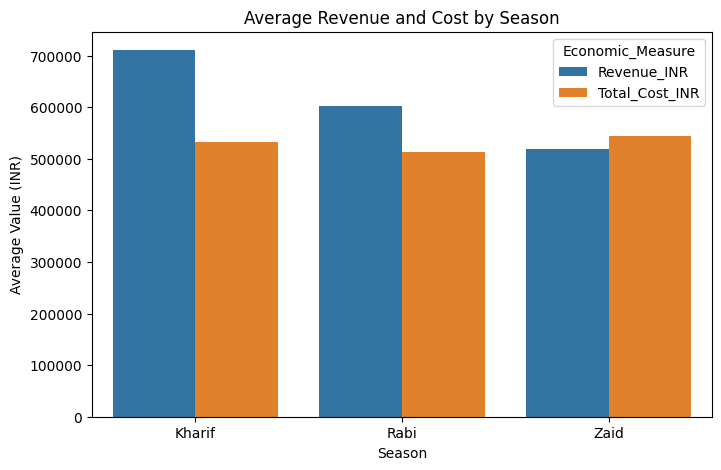

In [118]:
# Seasonal comparison of revenue and cost

plt.figure(figsize=(8, 5))

seasonal_economic_plot = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR']
].mean().reset_index()

seasonal_economic_plot = seasonal_economic_plot.melt(
    id_vars='Season',
    var_name='Economic_Measure',
    value_name='Average_Value'
)

sns.barplot(
    x='Season',
    y='Average_Value',
    hue='Economic_Measure',
    data=seasonal_economic_plot
)

plt.title('Average Revenue and Cost by Season')
plt.xlabel('Season')
plt.ylabel('Average Value (INR)')
plt.show()

### Interpretation

The bar chart compares average revenue and total cost across the three seasons. Kharif has the highest average revenue, and its revenue is clearly higher than its average cost. Rabi also has higher average revenue than average cost, but the difference is smaller than Kharif.

In Zaid, the average cost is higher than the average revenue. This explains the negative average profit observed for Zaid.

Overall, Kharif has the strongest economic performance, Rabi has moderate performance, and Zaid has the weakest economic performance.

# Key Insights

### Insight 1: Kharif shows the best overall agricultural performance
Kharif has the highest average yield of 5.63 tonnes/ha, compared with 5.04 tonnes/ha in Rabi and 4.64 tonnes/ha in Zaid. Kharif also has the highest average profit and water efficiency.

### Insight 2: Zaid has the weakest economic performance
Zaid has the lowest average profit of approximately -₹24,805. Its average cost is higher than its average revenue, which results in negative average profitability.

### Insight 3: Environmental conditions vary considerably across seasons
Kharif receives the highest average rainfall of about 849.20 mm and has the highest humidity of about 71.81%. Zaid receives the lowest rainfall of about 304.65 mm and has the highest average temperature of about 31.04°C.

### Insight 4: Water usage does not always result in better performance
Zaid has the highest average water usage at about 6419.89 m³, but it has the lowest average yield and profit among the three seasons. This indicates that higher water usage does not necessarily result in better agricultural performance.

### Insight 5: Drip irrigation shows the highest average yield
The irrigation comparison shows that Drip irrigation has the highest average yield among the four irrigation methods. This suggests that irrigation method is associated with differences in agricultural yield.

### Insight 6: Drip irrigation performs well in terms of profitability
The seasonal irrigation comparison shows that Drip irrigation has the highest average profit in both Kharif and Rabi. In Zaid, Drip has a positive average profit, while Flood and Rainfed show negative average profits.

### Insight 7: Water usage has a moderate positive relationship with yield
The correlation between water usage and yield is approximately 0.386, indicating a moderate positive relationship. This suggests that higher water usage is generally associated with higher yield, although water usage alone does not fully explain yield differences.

### Insight 8: Rainfall, temperature, and fertilizer show very weak relationships with yield
The correlation values for rainfall and yield (0.031), temperature and yield (0.010), and fertilizer usage and yield (approximately 0.00002) are very close to zero. This indicates that these variables do not show a strong linear relationship with yield in this dataset.

# **Recommendations**

Based on the analysis, the following recommendations can be made:

1. **Focus on better-performing seasons:** Kharif shows the highest average yield, profit, and water efficiency. Agricultural planning can give greater attention to practices that perform well during this season.

2. **Improve Zaid season performance:** Zaid has the lowest average yield and negative average profit. The reasons for higher costs and lower revenue should be investigated before increasing agricultural activities during this season.

3. **Use water efficiently:** Zaid has the highest average water usage but the lowest yield. Water usage should therefore be monitored carefully and efficient irrigation practices should be considered.

4. **Consider irrigation methods carefully:** Drip irrigation shows the highest average yield and strong profit performance across seasons. It can be considered when selecting irrigation methods, based on local conditions and cost.

5. **Consider crop differences:** Sugarcane has the highest average yield across all three seasons. Crop selection should consider both expected yield and the economic performance of the crop.

6. **Monitor seasonal environmental conditions:** Rainfall, temperature, and humidity vary considerably across seasons. These conditions should be considered when planning agricultural activities.

7. **Focus on cost management in Zaid:** Since the average cost in Zaid is higher than the average revenue, controlling production costs may help improve profitability.

### Limitations

- The analysis is based only on the variables available in the dataset.
- The detected outliers were retained because they may represent genuine agricultural observations.
- Correlation analysis shows relationships between variables but does not prove cause-and-effect relationships.
- Seasonal averages may hide differences between individual farms, crops, and irrigation methods.
- The analysis is based on the available records and may not represent all agricultural conditions.

# Conclusion


The Seasonal Agriculture Performance Analysis shows that agricultural performance varies across Kharif, Rabi, and Zaid seasons. Kharif performed best overall, with the highest average yield, profit, and water efficiency. Rabi showed moderate performance, while Zaid had the lowest average yield and negative average profit.

The analysis also showed clear differences in environmental conditions across seasons. Kharif had the highest rainfall and humidity, while Zaid had the lowest rainfall and humidity but the highest temperature. Resource usage was relatively similar for fertilizer and pesticides, while water usage was highest in Zaid.

Irrigation method also showed differences in agricultural performance, with Drip irrigation generally showing higher yield and better profit performance. Sugarcane had the highest average yield across all three seasons.

The correlation analysis showed that water usage had a moderate positive relationship with yield, while rainfall, temperature, and fertilizer usage showed very weak relationships with yield.

Overall, the analysis highlights the importance of considering seasonal conditions, irrigation methods, crop selection, resource usage, and economic factors when evaluating agricultural performance. These findings can support better seasonal planning and help identify areas where agricultural performance and profitability can be improved.